In [68]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
 

DATASET_ROOT = "/kaggle/input/datasets/ngelvish/braintumor/brain_tumor_dataset_final"


CLASSES = ["notumor", "glioma", "pituitary", "meningioma"]
COLORS  = ["#4CAF50", "#E53935", "#FB8C00", "#8E24AA"]

In [69]:
# Load image paths
data = {}
for cls in CLASSES:
    paths = []
    for split in ["Training", "Testing", ""]:
        folder = Path(DATASET_ROOT) / split / cls if split else Path(DATASET_ROOT) / cls
        if folder.exists():
            paths += list(folder.glob("*.jpg")) + list(folder.glob("*.png"))
    data[cls] = paths
    print(f"{cls}: {len(paths)} images")

notumor: 1268 images
glioma: 2823 images
pituitary: 2074 images
meningioma: 1884 images


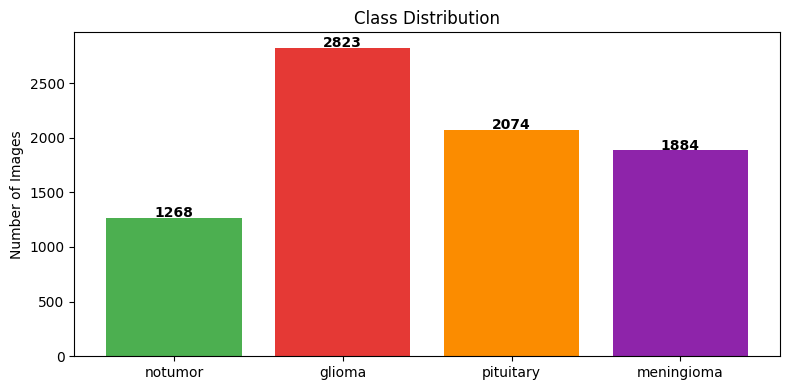

In [70]:
#Classs distribution
counts = [len(data[c]) for c in CLASSES]
 
plt.figure(figsize=(8, 4))
plt.bar(CLASSES, counts, color=COLORS)
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha="center", fontweight="bold")
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig("plot1_distribution.png", dpi=150)
plt.show()

In [71]:
# ── Class imbalance check ─────────────────────
counts = [len(data[c]) for c in CLASSES]
max_c  = max(counts)
min_c  = min(counts)
ratio  = max_c / min_c if min_c > 0 else float("inf")
 
print(f"\n  Most images  : {CLASSES[counts.index(max_c)]} ({max_c})")
print(f"  Least images : {CLASSES[counts.index(min_c)]} ({min_c})")
print(f"  Imbalance ratio (max/min) : {ratio:.2f}x")
 
if ratio > 2:
    print("  Significant class imbalance — consider augmentation or oversampling.")
else:
    print("  Classes are roughly balanced.")



  Most images  : glioma (2823)
  Least images : notumor (1268)
  Imbalance ratio (max/min) : 2.23x
  Significant class imbalance — consider augmentation or oversampling.


In [72]:
# Image size check
all_sizes = set()
for cls in CLASSES:
    for path in data[cls][:50]:
        img = cv2.imread(str(path))
        if img is not None:
            all_sizes.add(img.shape[:2])
 
print(f"\n  Unique image sizes found : {len(all_sizes)}")
if len(all_sizes) == 1:
    print(f"    All images are the same size: {all_sizes.pop()}")
else:
    print(f"    Mixed sizes — resizing needed before training.")
    for s in list(all_sizes)[:5]:
        print(f"      {s}")
 
print("\n" + "=" * 65)


  Unique image sizes found : 36
    Mixed sizes — resizing needed before training.
      (630, 630)
      (234, 215)
      (238, 212)
      (540, 504)
      (442, 442)



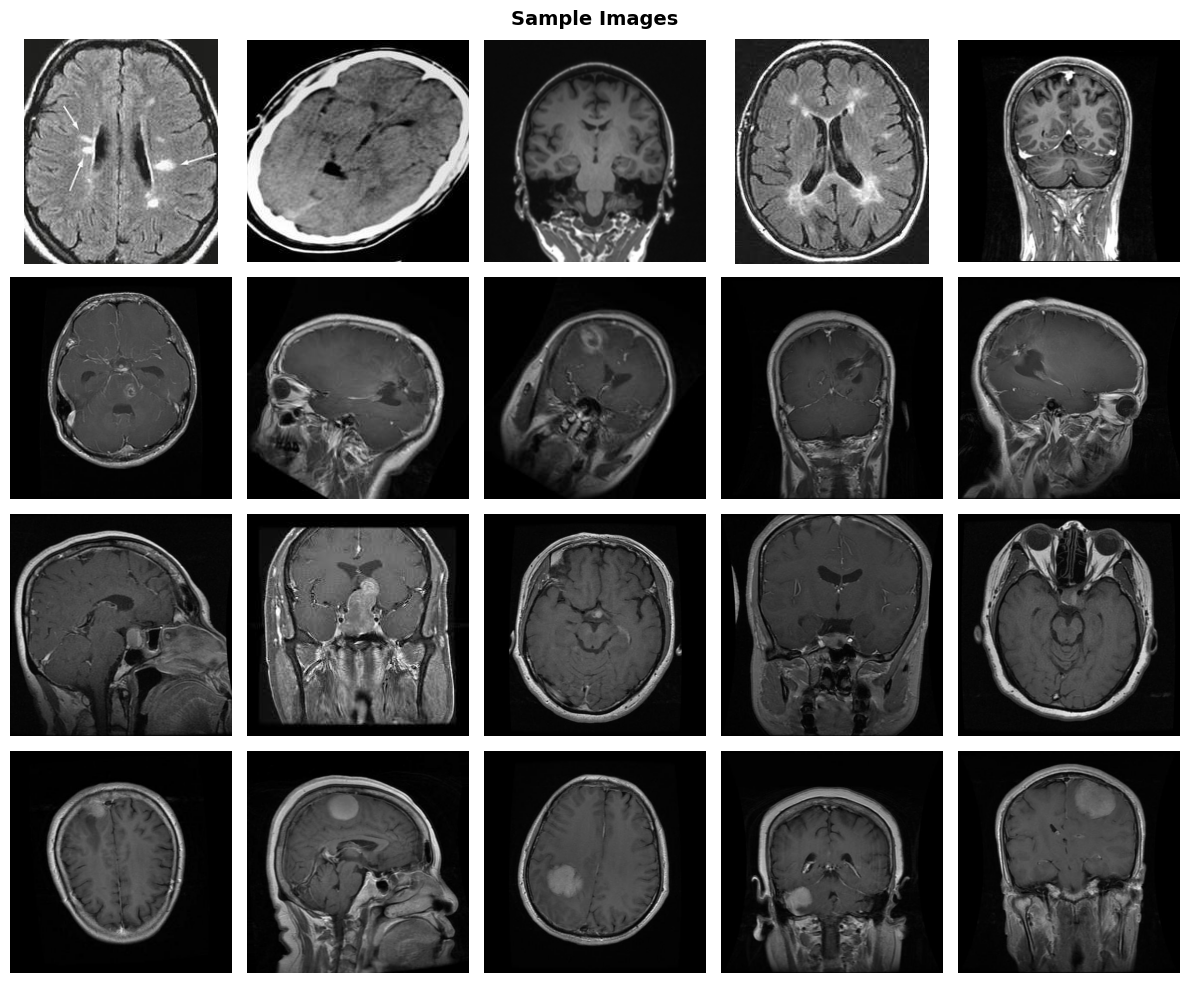

In [73]:
#  3. Sample images
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
fig.suptitle("Sample Images", fontsize=14, fontweight="bold")
 
for row, cls in enumerate(CLASSES):
    samples = np.random.choice(data[cls], min(5, len(data[cls])), replace=False)
    for col, path in enumerate(samples):
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img)
        axes[row][col].axis("off")
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=10, fontweight="bold",
                                      color=COLORS[row])
 
plt.tight_layout()
plt.savefig("plot2_samples.png", dpi=150)
plt.show()

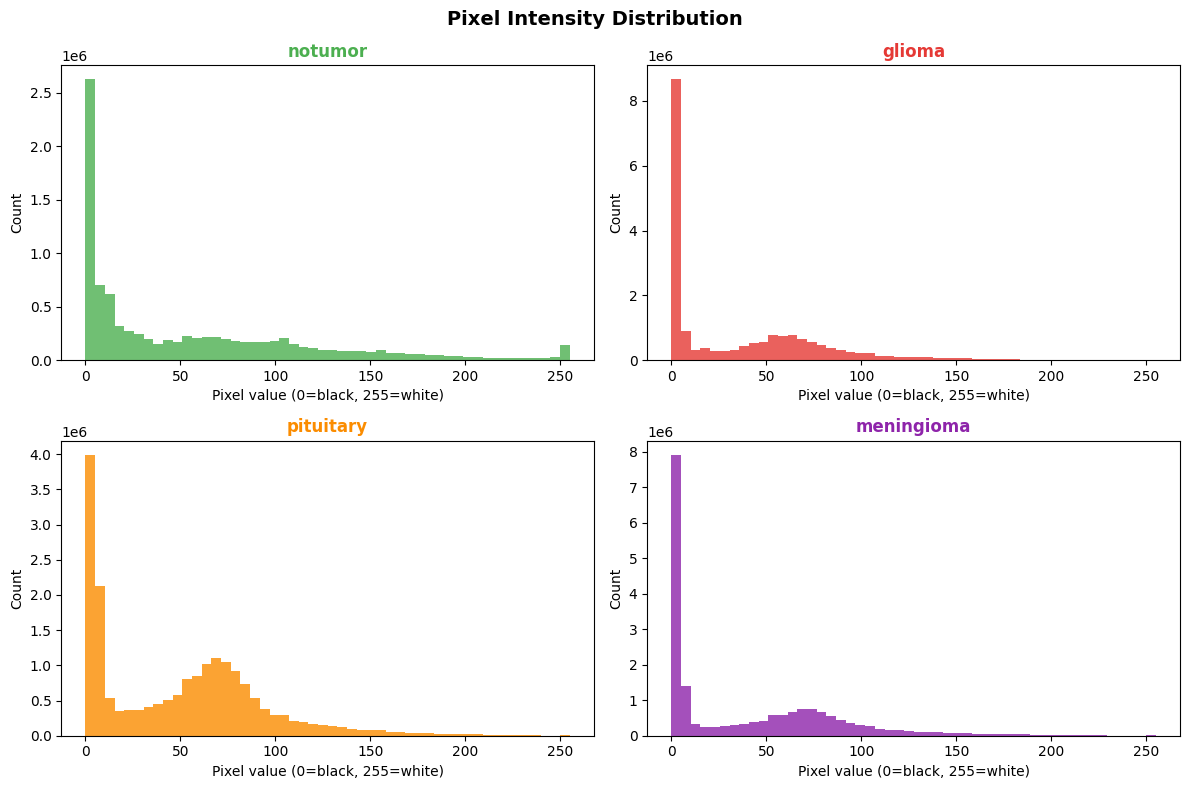

In [74]:
#4. Pixel intensity histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Pixel Intensity Distribution", fontsize=14, fontweight="bold")
 
for ax, cls, color in zip(axes.flatten(), CLASSES, COLORS):
    pixels = []
    for path in data[cls][:100]:                          # use first 100 images
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            pixels.append(img.flatten())
    all_pixels = np.concatenate(pixels)
    ax.hist(all_pixels, bins=50, color=color, alpha=0.8)
    ax.set_title(cls, fontweight="bold", color=color)
    ax.set_xlabel("Pixel value (0=black, 255=white)")
    ax.set_ylabel("Count")
 
plt.tight_layout()
plt.savefig("plot3_intensity.png", dpi=150)
plt.show()

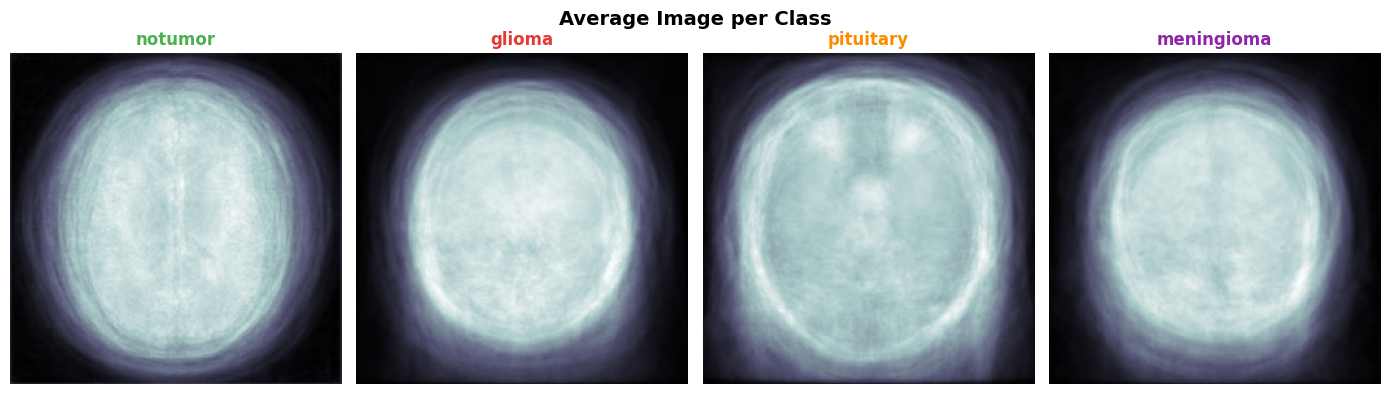


✅ Done! 4 plots saved.


In [75]:
#5. Mean image per class
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("Average Image per Class", fontsize=14, fontweight="bold")
 
for ax, cls, color in zip(axes, CLASSES, COLORS):
    stack = []
    for path in data[cls][:200]:
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            stack.append(cv2.resize(img, (256, 256)).astype(np.float32))
    mean_img = np.mean(stack, axis=0)
    ax.imshow(mean_img, cmap="bone")
    ax.set_title(cls, fontweight="bold", color=color)
    ax.axis("off")
 
plt.tight_layout()
plt.savefig("plot4_mean_images.png", dpi=150)
plt.show()
 
print("\n✅ Done! 4 plots saved.")

In [76]:
#  Corruption / unreadable image check

print("\n=== Corruption Check ===")
bad = 0
for cls in CLASSES:
    cls_bad = 0
    for p in data.get(cls, []):
        try:
            img = cv2.imread(str(p))
            if img is None:
                cls_bad += 1
        except Exception:
            cls_bad += 1
    print(f"  {cls:<14} unreadable: {cls_bad}")
    bad += cls_bad
print(f"  Total unreadable: {bad}")
 
# ─────────────────────────────────────────────
# Done
# ─────────────────────────────────────────────
print(f"\n EDA complete! Figures saved to '{OUTPUT_DIR}/' (if SAVE_FIGS=True)")
 



=== Corruption Check ===
  notumor        unreadable: 0
  glioma         unreadable: 0
  pituitary      unreadable: 0
  meningioma     unreadable: 0
  Total unreadable: 0

 EDA complete! Figures saved to './eda_output/' (if SAVE_FIGS=True)
